In [56]:
%load_ext autoreload
%autoreload 2
import pylupnt as pnt
import numpy as np
import utils
import plotting
import pprint
import matplotlib.pyplot as plt
from algorithms import PntSchedulingProblem, SmdpForwardSearchSolver, SmdpMctsSolver, DiscreteTimeIpSolver, RuleBasedSolver
from algorithms import State, Action, Request, ServiceWindow

pp = pprint.PrettyPrinter()
# Backend for matplotlib (inline, TkAgg, Qt5Agg, WXAgg, GTKAgg, Agg, ps, pdf, svg, cairo, Macosx, WebAgg, nbAgg, template)
%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


# Toy Problem

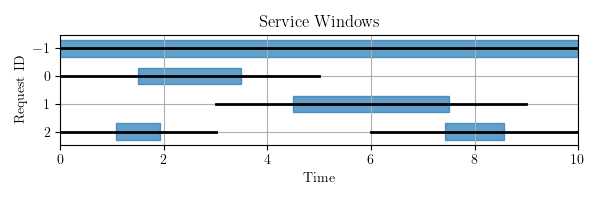

In [2]:
figsize = (6, 2)

requests = [
    Request(id=-1, user_id=-1, rv=None, start=0, end=10, duration=10),  # Dummy request
    Request(id=0, user_id=1, rv=None, start=0, end=10, duration=2),
    Request(id=1, user_id=2, rv=None, start=0, end=10, duration=3),
    Request(id=2, user_id=3, rv=None, start=0, end=10, duration=2),
]

service_windows = [
    ServiceWindow(
        id=-1, request_id=-1, start=0, end=10, reward=0, power_gen=0, data_gen=0
    ),  # Dummy service window
    ServiceWindow(
        id=0, request_id=0, start=0, end=5, reward=1, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=1, request_id=1, start=3, end=9, reward=2, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=0, end=3, reward=3, power_gen=-1, data_gen=1
    ),
    ServiceWindow(
        id=2, request_id=2, start=6, end=10, reward=5, power_gen=-1, data_gen=1
    ),
]

transition_times = np.ones((len(service_windows), len(service_windows)))
transition_times[np.diag_indices(len(service_windows))] = 0
energy_gen_func = lambda ts, te: 0.25 * (te - ts)
data_gen_func = lambda ts, te: -0.25 * (te - ts)


problem = PntSchedulingProblem(
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    N_max_actions=50,
    min_action_duration=1,
    max_energy=10,
    min_energy=2,
    max_data=10,
    min_data=2,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

plotting.plot_requests_service_windows(requests, service_windows, figsize=figsize)

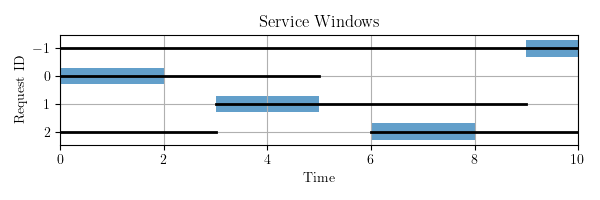

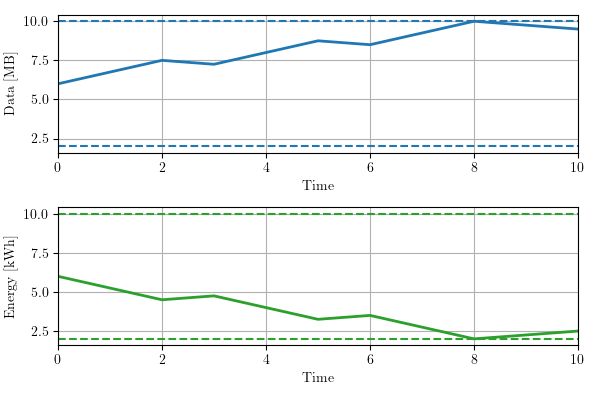

Total reward: 7.33


In [3]:
# Forward search
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy = solver.solve(s, d=100, gamma=0.9)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, figsize=figsize
)
plt.show()
plotting.plot_resources(problem, policy, figsize=figsize)
plt.show()
print(f"Total reward: {problem.total_reward(policy):.2f}")

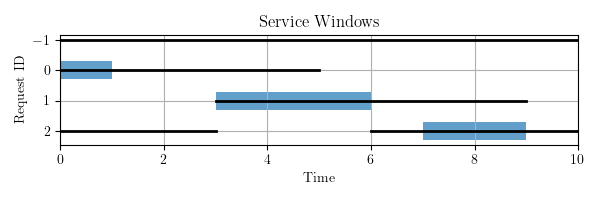

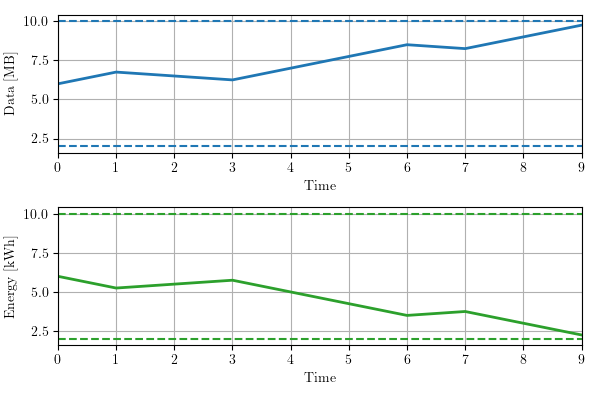

Total reward: 7.50


In [4]:
# MCTS
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy = solver.solve(s, d=10, gamma=0.9, n=int(5e3), c=10)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, figsize=figsize
)
plt.show()
plotting.plot_resources(problem, policy, figsize=figsize)
plt.show()
print(f"Total reward: {problem.total_reward(policy):.2f}")

Set parameter Username
Academic license - for non-commercial use only - expires 2025-03-11
optimal


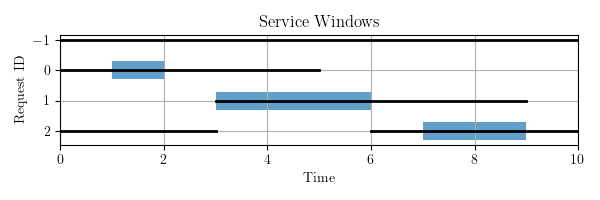

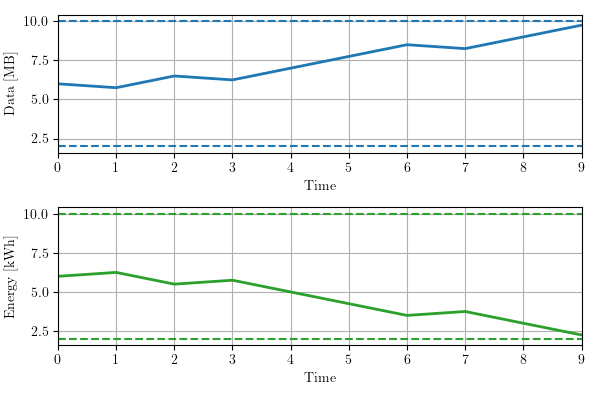

Total reward: 7.50


In [5]:
# IP
solver = DiscreteTimeIpSolver(problem)
policy = solver.solve(s, time_step=1)
plotting.plot_requests_service_windows(
    requests, service_windows, policy, figsize=figsize
)
plt.show()
plotting.plot_resources(problem, policy, figsize=figsize)
plt.show()
print(f"Total reward: {problem.total_reward(policy):.2f}")

# Experiment 1

## Users

In [6]:
import pathfinder_data

orbital_elements = pathfinder_data.orbital_elements.copy()
users = pathfinder_data.users.copy()

# Epoch (TAI)
epoch_0 = pnt.SpiceInterface.string_to_tai("2026/1/01 00:00:00.000 UTC")

# Classical orbital elements (a, e, i, W, w, M) [km, -, rad, rad, rad, rad]
coe_OP = orbital_elements
coe_OP[2:] = np.deg2rad(coe_OP[2:])
rv0_moon_sat_OP = pnt.classical_to_cartesian(coe_OP, pnt.MU_MOON)
rv0_moon_sat_mi = pnt.CoordConverter.convert(epoch_0, rv0_moon_sat_OP, pnt.OP, pnt.MI)

# Time
sma = coe_OP[0]  # [km] Semi-major axis
period = 2 * np.pi * np.sqrt(np.power(sma, 3) / pnt.MU_MOON)  # [s] Orbital period
Dt = 5 * pnt.SECS_PER_MINUTE  # [s] Simulation time step
dt = 5 * pnt.SECS_PER_MINUTE  # [s] Propagation time step
tf = 1 * pnt.SECS_PER_DAY  # [s] Simulation final time
N_t = int(tf / Dt)  # [-] Number of time steps
tspan = np.linspace(0, tf, N_t)  # [s] Time since first epoch
epochs = epoch_0 + tspan  # [s] Epochs (TAI)

# Dynamics (three-body)
dynamics = pnt.NBodyDynamics()
dynamics.set_primary_body(pnt.Body.Moon())
dynamics.add_body(pnt.Body.Earth())
dynamics.set_time_step(dt)

# Propagation
# rv_{from}_{to}_{frame} [km, km/s] (x, y, z, vx, vy, vz)
rv_moon_sat_mi = dynamics.propagate(rv0_moon_sat_mi, epoch_0, epochs)
rv_moon_sat_pa = pnt.CoordConverter.convert(epochs, rv_moon_sat_mi, pnt.MI, pnt.PA)
rv_moon_earth_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.EARTH)
rv_moon_earth_pa = pnt.CoordConverter.convert(epochs, rv_moon_earth_mi, pnt.MI, pnt.PA)
rv_moon_sun_mi = pnt.SpiceInterface.get_body_pos_vel(epochs, pnt.MOON, pnt.SUN)
rv_moon_sun_pa = pnt.CoordConverter.convert(epochs, rv_moon_sun_mi, pnt.MI, pnt.PA)

Loaded All SPICE Kernels
Loaded Chebyshev coefficients for 14 planets.


In [7]:
def propagate_orbital_user(user: dict) -> np.array:
    """
    Propagate a user on orbit around the Moon.
    :param coe: [a, e, i, W, w, M] [km, -, deg, deg, deg, deg]
    :param frame: Frame
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    coe = user["orbital_elements"].copy()
    frame = user["frame"]
    coe[2:] = np.deg2rad(coe[2:])
    rv0 = pnt.classical_to_cartesian(coe, pnt.MU_MOON)
    rv0_mi = pnt.CoordConverter.convert(epoch_0, rv0, frame, pnt.MI)
    rv_mi = dynamics.propagate(rv0_mi, epoch_0, epochs)
    return rv_mi


def propagate_surface_user(user: dict) -> np.array:
    """
    Propagate a user on the surface of the Moon.
    :param lat_lon_alt: [lat, lon, alt] [deg, deg, km]
    :return: [x, y, z, vx, vy, vz] [km, km/s]
    """
    lat_lon_alt = user["location"].copy()
    lat_lon_alt[:2] = np.deg2rad(lat_lon_alt[:2])
    rv_pa = np.zeros((N_t, 6))
    rv_pa[:, :3] = pnt.geographical_to_cartesian(lat_lon_alt, pnt.R_MOON)
    return rv_pa


# Users
N_users = len(users)
user_type = np.array([user["type"] for user in users])
rv_moon_user_mi = np.zeros((N_users, N_t, 6))
rv_moon_user_pa = np.zeros((N_users, N_t, 6))
az_el_rho = np.zeros((N_users, N_t, 3))
for i, user in enumerate(users):
    if user["type"] == "orbital":
        rv_moon_user_mi[i] = propagate_orbital_user(user)
        rv_moon_user_pa[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_mi[i], pnt.MI, pnt.PA
        )
    elif user["type"] == "surface":
        rv_moon_user_pa[i] = propagate_surface_user(user)
        rv_moon_user_mi[i] = pnt.CoordConverter.convert(
            epochs, rv_moon_user_pa[i], pnt.PA, pnt.MI
        )
    else:
        raise ValueError("Invalid user type")

    az_el_rho[i] = pnt.cartesian_to_azimuth_elevation_range(
        rv_moon_user_mi[i, :, :3], rv_moon_sat_mi[:, :3]
    )

surface_elev_mask = np.deg2rad(15)  # [rad] Elevation mask
orbital_elev_mask = np.deg2rad(2)  # [rad] Elevation mask
max_elevation = np.max(az_el_rho[:, :, 1], axis=1)
min_elevation = np.maximum(surface_elev_mask, max_elevation - np.deg2rad(90))
min_elevation[user_type == "orbital"] = orbital_elev_mask
print("Max elevation (geometry)   ", np.rad2deg(max_elevation).round(0))
print("Min elevation (requirement)", np.rad2deg(min_elevation).round(0))
user_visible = np.greater_equal(az_el_rho[:, :, 1], min_elevation[:, None])

Max elevation (geometry)    [79. 55. 42. 64. 79. 18.]
Min elevation (requirement) [ 2. 15. 15. 15.  2. 15.]


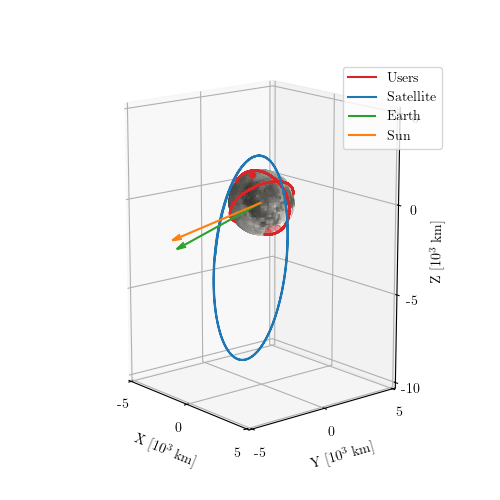

In [8]:
plotting.plot_satellites_users(
    rv_moon_sat_mi, rv_moon_user_mi, rv_moon_earth_mi, rv_moon_sun_mi, user_type
)

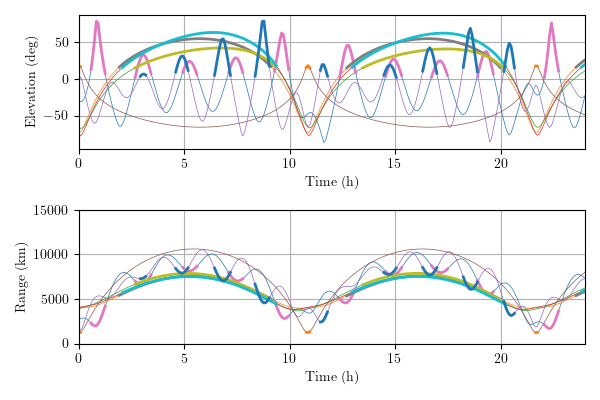

In [9]:
plotting.plot_elevation_range(tspan, az_el_rho, user_visible)

In [10]:
contact_durations = list[np.array]()
contact_start_ends = list[np.array]()
for i, user in enumerate(users):
    starts, ends = utils.get_start_end_indexes(user_visible[i])
    contact_start_ends.append(np.vstack((starts, ends)).T)
    contact_durations.append((ends - starts) * Dt / pnt.SECS_PER_MINUTE)
total_contact_durations = np.array([x.sum() for x in contact_durations])
contact_durations_pathfinder = np.array([user["contact"] for user in users])

print("Contact durations [min]")
pp.pprint(contact_durations)
print("Total contact durations [min]")
pp.pprint(total_contact_durations)
print("Pathfinder contact durations [min]")
pp.pprint(contact_durations_pathfinder)

Contact durations [min]
[array([45., 50., 45., 45., 45., 50., 50., 50., 50., 45.]),
 array([435., 440.,  30.]),
 array([400., 400.]),
 array([440., 440.,  15.]),
 array([ 5., 20., 40., 50., 45., 25., 40., 45., 45., 35.]),
 array([10., 15., 10.])]
Total contact durations [min]
array([475., 905., 800., 895., 350.,  35.])
Pathfinder contact durations [min]
array([150, 467, 529, 248, 100,  23])


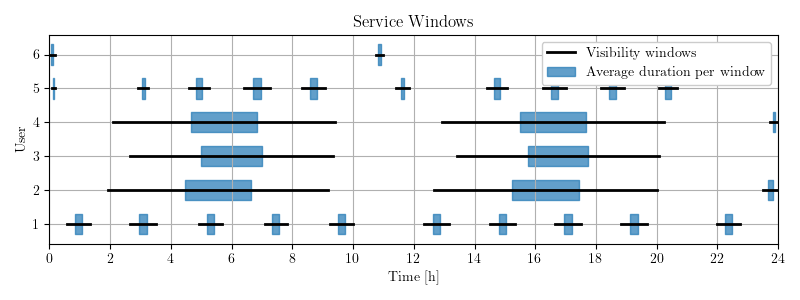

In [11]:
import matplotlib.pyplot as plt

duration_factor = 0.3
time_multiplier = Dt / pnt.SECS_PER_HOUR
plotting.plot_service_windows(contact_start_ends, duration_factor, time_multiplier)
plt.xlim(0, tf / pnt.SECS_PER_HOUR)
plt.xticks(np.arange(0, tf / pnt.SECS_PER_HOUR + 1, 2))
plt.tight_layout()
plt.show()

In [215]:
# Time in hours
duration_factor = 0.3

# Requests
requests = list[Request]()
requests.append(
    Request(
        id=-1,
        user_id=-1,
        rv=None,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
        duration=tf / pnt.SECS_PER_HOUR,
        priority=0,
    ),  # Dummy request
)
resquest_id = 0
for i, user in enumerate(users):
    requests.append(
        Request(
            id=resquest_id,
            user_id=user["id"],
            rv=rv_moon_user_mi[i],
            start=0,
            end=tf / pnt.SECS_PER_HOUR,
            duration=total_contact_durations[i]
            * pnt.SECS_PER_MINUTE
            / pnt.SECS_PER_HOUR
            * duration_factor,
        )
    )
    resquest_id += 1
N_requests = len(requests)

# Service windows
service_windows = list[ServiceWindow]()
window_id = 0
service_windows.append(
    ServiceWindow(
        id=-1,
        request_id=-1,
        start=0,
        end=tf / pnt.SECS_PER_HOUR,
        reward=0,
        power_gen=0,
        data_gen=0,
    )  # Dummy service window
)
for i, request in enumerate(requests[1:]):
    for start, end in contact_start_ends[i]:
        service_windows.append(
            ServiceWindow(
                id=window_id,
                request_id=request.id,
                start=round(start * Dt / pnt.SECS_PER_HOUR, 1),
                end=round(end * Dt / pnt.SECS_PER_HOUR, 1),
                reward=1,
                power_gen=-1,
                data_gen=1,
            )
        )
        window_id += 1
N_service_windows = len(service_windows)

# Transition times
transition_times = np.ones((N_service_windows, N_service_windows))
transition_times *= 0.2  # hours
transition_times[np.diag_indices(N_service_windows)] = 0

# Energy and data generation functions
energy_gen_func = lambda ts, te: 0.25 * (te - ts)
data_gen_func = lambda ts, te: -0.25 * (te - ts)

# Problem
problem = PntSchedulingProblem(
    requests=requests,
    service_windows=service_windows,
    transition_times=transition_times,
    N_max_actions=100,
    min_action_duration=1,
    max_energy=10,
    min_energy=2,
    max_data=10,
    min_data=2,
    energy_gen_func=energy_gen_func,
    data_gen_func=data_gen_func,
)

In [216]:
# Forward search
np.random.seed(0)
s = problem.initial_state()
solver = SmdpForwardSearchSolver(problem)
policy_fs = solver.solve(s, d=3, gamma=0.7)

# Metrics
print(f"Total reward: {problem.total_reward(policy_fs):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_fs)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())),2))

Solving Forward Search (progress in hours): 100%|██████████| 24/24 [00:01<00:00, 17.04it/s]

Total reward: 4.09
Percentage of requests served:
{0: 84.21, 1: 33.15, 2: 100.0, 3: 0.0, 4: 91.43, 5: 100.0}
Total: 68.13


In [217]:
# MCTS
np.random.seed(0)
s = problem.initial_state()
solver = SmdpMctsSolver(problem)
policy_mcts = solver.solve(s, d=5, gamma=0.7, n=int(100), c=3)

# Metrics
print(f"Total reward: {problem.total_reward(policy_mcts):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_mcts)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())),2))

Solving Forward Search (progress in hours): 100%|██████████| 24/24 [00:01<00:00, 18.71it/s]

Total reward: 4.00
Percentage of requests served:
{0: 100.0, 1: 11.05, 2: 75.0, 3: 22.35, 4: 91.43, 5: 100.0}
Total: 66.64


In [244]:
# IP
np.random.seed(0)
solver = DiscreteTimeIpSolver(problem)
policy_ip = solver.solve(s, time_step=0.2)

# Metrics
print(f"Total reward: {problem.total_reward(policy_ip):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_ip)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())),2))

Service window 18 has duration 0. Try decreasing time step.
                                     CVXPY                                     
                                     v1.4.2                                    
(CVXPY) Mar 16 02:20:40 AM: Your problem has 840 variables, 5241 constraints, and 0 parameters.
(CVXPY) Mar 16 02:20:41 AM: It is compliant with the following grammars: DCP, DQCP
(CVXPY) Mar 16 02:20:41 AM: (If you need to solve this problem multiple times, but with different data, consider using parameters.)
(CVXPY) Mar 16 02:20:41 AM: CVXPY will first compile your problem; then, it will invoke a numerical solver to obtain a solution.
(CVXPY) Mar 16 02:20:41 AM: Your problem is compiled with the CPP canonicalization backend.
-------------------------------------------------------------------------------
                                  Compilation                                  
-------------------------------------------------------------------------------
(CVXPY) 

In [228]:
# Rule-based
solver = RuleBasedSolver(problem)
policy_rb = solver.solve(s)

# Metrics
print(f"Total reward: {problem.total_reward(policy_rb):.2f}")
print("Percentage of requests served:")
percentage = problem.percentage_completed(policy_rb)
pp.pprint(percentage)
print("Total:", round(np.mean(list(percentage.values())),2))

Total reward: 3.99
Percentage of requests served:
{0: 100.0, 1: 99.45, 2: 0.0, 3: 0.0, 4: 100.0, 5: 100.0}
Total: 66.58


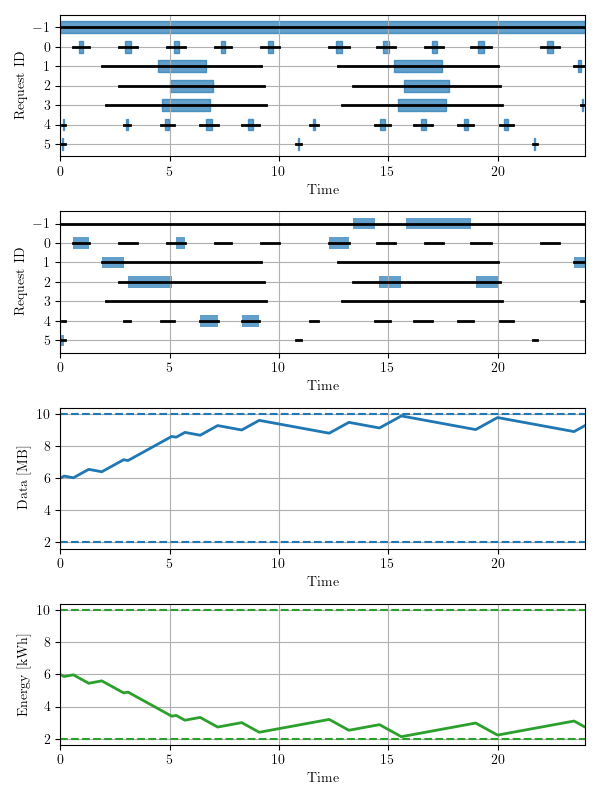

In [220]:
# Forward search
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_fs, ax=axs[1])
plotting.plot_resources(problem, policy_fs, ax=axs[2:4])
plt.show()

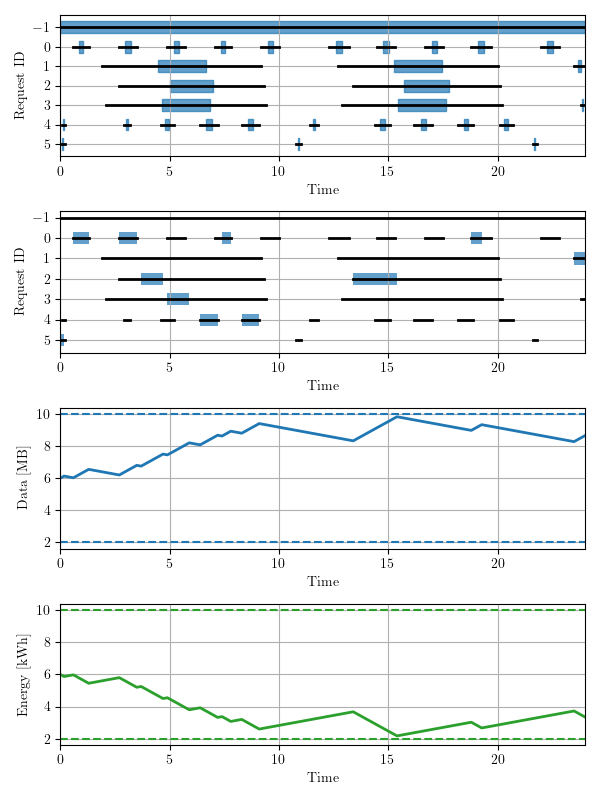

In [221]:
# MCTS
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_mcts, ax=axs[1])
plotting.plot_resources(problem, policy_mcts, ax=axs[2:4])
plt.show()

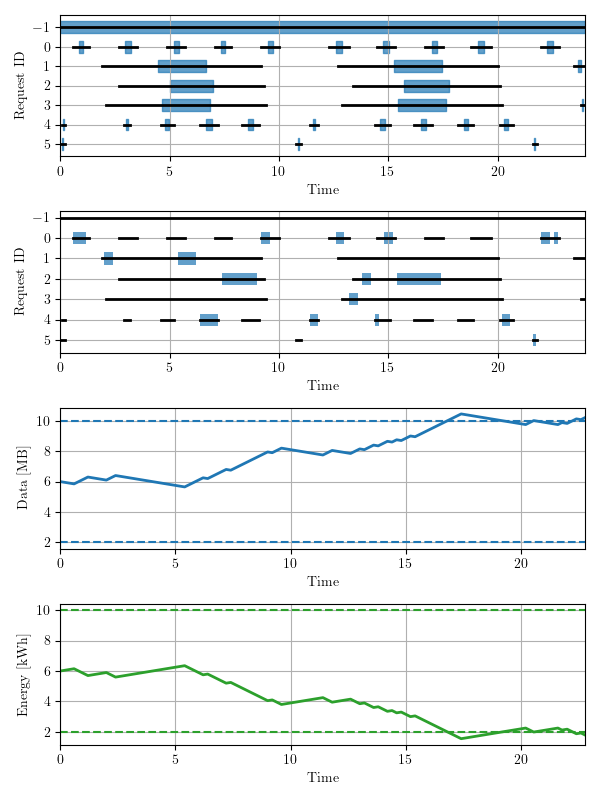

In [236]:
# IP
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_ip, ax=axs[1])
plotting.plot_resources(problem, policy_ip, ax=axs[2:4])
plt.show()

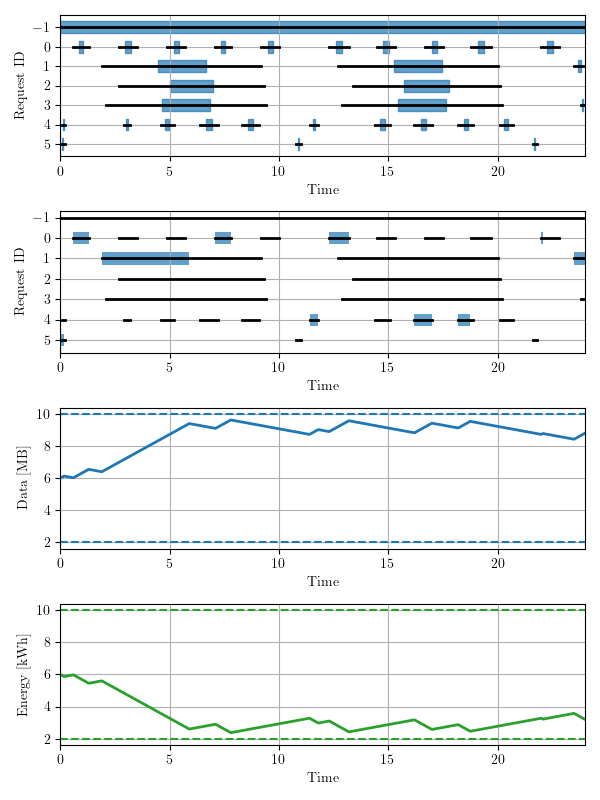

In [227]:
# IP
fig, axs = plt.subplots(4, 1, figsize=(6, 8))
plotting.plot_requests_service_windows(requests, service_windows, ax=axs[0])
plotting.plot_requests_service_windows(requests, service_windows, policy_rb, ax=axs[1])
plotting.plot_resources(problem, policy_rb, ax=axs[2:4])
plt.show()